# Imports

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from openpyxl import load_workbook
from functools import reduce
import re
import unicodedata
import json

# Read Data File

In [22]:
file = "FatigueData-AM2022.xlsx"

# read all sheets
all_sheets = pd.read_excel(file, sheet_name=None, header=0)

print(all_sheets.keys())

dict_keys(['S-N', 'e-N', 'dadn', 'parameter'])


In [23]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print(f"\nDataset {i}")
    print("Sheet:", sheet_name)
    print(df.columns.tolist())


Dataset 1
Sheet: S-N
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Dataset 2
Sheet: e-N
['dataset id', 'life\nN (cycle)', 'strain amplitude\nεa (mm/mm)', 'runout']

Dataset 3
Sheet: dadn
['dataset id', 'stress intensity factor range\nΔK (MPa*m^(1/2))', 'crack growth rate \nda/dn (m/cycle)']

Dataset 4
Sheet: parameter
['Unnamed: 0', 'metadata', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'fatigue', 'Unnamed: 10', 'materials', 'AM', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'processing', 'testing', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'static mechanical properties', 'Unnamed: 43', 'Un

In [24]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print("\n" + "="*60)
    print(f"Sheet {i}: {sheet_name}")
    print("="*60)

    print(df.describe())

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    # print("\nFirst rows:")
    # print(df.head())

    print("\nMissing values:")
    print(df.isnull().sum())


Sheet 1: S-N
         dataset id  life\nN (cycle)  stress amplitude\nσa (MPa)       runout
count  15146.000000     1.514600e+04                15146.000000  15146.00000
mean     792.986003     1.844821e+07                  285.818193      0.12221
std      457.581397     1.472127e+08                  189.421194      0.32754
min        1.000000     9.710731e+00                    5.760575      0.00000
25%      396.000000     6.502688e+04                  138.464799      0.00000
50%      780.000000     2.443496e+05                  249.958188      0.00000
75%     1187.000000     1.599869e+06                  375.990143      0.00000
max     1610.000000     8.496147e+09                 1591.682267      1.00000

Shape:
(15146, 4)

Columns:
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Missing values:
dataset id                    0
life\nN (cycle)               0
stress amplitude\nσa (MPa)    0
runout                        0
dtype: int64

Sheet 2: e-N
        d

# Clean Data

## Remove Merged Headers
remove merged headers in row 1 of "parameters" and make row 2 the header row

In [25]:
# reread only the parameter sheet with row 2 as header
all_sheets["parameter"] = pd.read_excel(
    file,
    sheet_name="parameter",
    header=1
)

In [26]:
# # modify workbook so row 2 is the header row for "parameter" sheet

# # load workbook
# wb = load_workbook(file)
# ws = wb["parameter"]

# #for ws in wb.worksheets:
# ws.delete_rows(0)   # delete first row

# wb.save("data_fatigue_headersfixed.xlsx")

# file2 = "data_fatigue_headersfixed.xlsx"
# xls = pd.ExcelFile(file2)

# all_sheets = pd.read_excel(file2, sheet_name=None)

The "parameters" sheet includes many missing values. The others include none. 

## Merged Sheets
merge all the sheets where possible on dataset id

In [27]:
dfs = []

for sheet_name, sheet_df in all_sheets.items():
    sheet_df = sheet_df.copy()

    # standardize dataset id column before merge
    sheet_df.columns = [
        str(col).strip().lower().replace(" ", "_")
        for col in sheet_df.columns
    ]

    # make sure dataset_id is consistent
    sheet_df = sheet_df.rename(columns={
        "dataset_id": "dataset_id",
        "datasetid": "dataset_id",
        "dataset_id_": "dataset_id",
        "dataset": "dataset_id"
    })

    dfs.append(sheet_df)

merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="dataset_id",
        how="outer",
        suffixes=("", "_dup")
    ),
    dfs
)

print(merged_df.shape)
print(merged_df.columns.tolist())

(195047, 55)
['dataset_id', 'life\nn_(cycle)', 'stress_amplitude\nσa_(mpa)', 'runout', 'life\nn_(cycle)_dup', 'strain_amplitude\nεa_(mm/mm)', 'runout_dup', 'stress_intensity_factor_range\nδk_(mpa*m^(1/2))', 'crack_growth_rate_\nda/dn_(m/cycle)', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_\n(w)', 'scan_speed_\n(mm/s)', 'hatch_space_\n(μm)', 'layer_thickness_\n(μm)', 'preheat_temperature_\n(°c)', 'direciton_of_specimen_\n(°)', 'am_environment', 'scan_pattern', 'layer_scan_rotation_\n(°)', 'voltage_\n(v)', 'current_\n(a)', 'speed_function', 'powder_feed_rate_\n(g/s)', 'wire_feed_rate_\n(mm/s)', 'types_of_feedstock', 'size_of_feedstock_\n(μm)', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_\n(°c)', 'fatigue_environment', 'load_ratio', 'frequency_\n(hz)', 

## Clean Column Names
clean merged dataframe

In [28]:
def clean_column_name(col):
    col = str(col)

    symbol_map = {
        "σ": "sigma",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
        "ε": "epsilon",
    }

    for symbol, replacement in symbol_map.items():
        col = col.replace(symbol, replacement)

    col = unicodedata.normalize("NFKD", col)
    col = col.encode("ascii", "ignore").decode()
    col = col.strip().lower()
    col = col.replace(" ", "_").replace("/", "_")
    col = re.sub(r"[^a-z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    col = col.replace("\n", "").replace("_x", "") 

    return col

clean_merged_df = merged_df.copy()
clean_merged_df.columns = [
    clean_column_name(col)
    for col in clean_merged_df.columns
]

# fix known typo
clean_merged_df = clean_merged_df.rename(columns={
    "direciton_of_specimen": "direction_of_specimen"
})

print(clean_merged_df.columns.tolist())

['dataset_id', 'lifen_cycle', 'stress_amplitudesigmaa_mpa', 'runout', 'lifen_cycle_dup', 'strain_amplitudeepsilona_mm_mm', 'runout_dup', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crossse

## Remove Columns
remove irrelevant or duplicate columns

In [44]:
cols_to_drop = [
    "runout",
    "runout_dup",
    "title",
    "authors",
    "source_of_the_publication",
    "year_of_publication",
    "institution",
    "country_and_region",
    "funding_agency",
    "doi",
    "rating_score",
    "runout_y",
    "lifen_cycle_y",
    "lifen_cycle_dup"
]

clean_merged_df = clean_merged_df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

print(clean_merged_df.columns.to_list())

['dataset_id', 'lifen_cycle', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


## Final Working Dataframe
final, merged dataframe
use this to deal with missing values

In [45]:
df = clean_merged_df.copy()

print(df.shape)
print(df.columns.tolist())
df.head()

(195047, 43)
['dataset_id', 'lifen_cycle', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


,dataset_id,lifen_cycle,stress_amplitudesigmaa_mpa,strain_amplitudeepsilona_mm_mm,stress_intensity_factor_rangek_mpam1_2,crack_growth_rate_da_dn_m_cycle,types_of_fatigue_data,method_of_extraction,name_of_the_material,types_of_am,...,fatigue_machine,fatigue_standard,load_control,specimens_description,critical_crosssection_size_of_specimensmm,stress_concentration_factor_of_specimens,youngs_modulus_gpa,yield_strength_mpa,ultimate_tensile_strength_mpa,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,color and shape,316L,L-PBF,...,Schenck PSB100,NaN,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,color and shape,316L,L-PBF,...,Schenck PSB100,NaN,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,color and shape,316L,L-PBF,...,Schenck PSB100,NaN,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,color and shape,316L,L-PBF,...,Schenck PSB100,NaN,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,color and shape,316L,L-PBF,...,Schenck PSB100,NaN,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2


## Missing Values
missing values in relevant columns in "parameters" sheet are handled

In [46]:
# print("\nColumns:")
# print(df.columns.tolist())
        
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
dataset_id                                        0
lifen_cycle                                  179901
stress_amplitudesigmaa_mpa                   179901
strain_amplitudeepsilona_mm_mm               193207
stress_intensity_factor_rangek_mpam1_2        16986
crack_growth_rate_da_dn_m_cycle               16986
types_of_fatigue_data                             0
method_of_extraction                              0
name_of_the_material                              0
types_of_am                                       0
am_machine                                    26539
power_w                                       69208
scan_speed_mm_s                               62152
hatch_space_m                                 99171
layer_thickness_m                             47812
preheat_temperature_c                        152528
direction_of_specimen                         14294
am_environment                               116566
scan_pattern                                 15

## Standarize Column Names

In [32]:
# standardize column names across datasets
for sheet_name, df in all_sheets.items():
    
    rename_map = {
        "stress(mpa)": "stress_max",
        "stress_mpa": "stress_max",
        "stressmpa": "stress_max",
        "s_mpa": "stress_max",
        "sa_mpa": "stress_amp",
        "cycles": "Nf",
        "fatigue_life": "Nf",
        "n": "Nf",
        "nf": "Nf",
        "î”k_(mpaâˆšm)": "deltaK",
        "ik_mpaasm": "deltaK",
        "dmax": "sqrt_A",
        "r": "r-ratio",
        "rratio": "r-ratio",
        "t": "temperature_k",
        "kt": "Kt"
    }

    symbol_map = {
        "σ": "s",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
    }
    
    # df = df.rename(columns=rename_map)

    # print(df.columns.to_list())

In [33]:
# cleanup column names across datasets
cleaned_sheets = {}

for sheet_name, df in all_sheets.items():
    
    cleaned_cols = []
    
    for col in df.columns:

        col = str(col)

        # replace Greek letters for readability
        for symbol, replacement in symbol_map.items():
            col = col.replace(symbol, replacement)

        # clean column names
        col = unicodedata.normalize("NFKD", col)
        col = col.encode("ascii", "ignore").decode()
        col = col.strip().lower().replace(" ", "_").replace("/", "_").strip("_")
        col = re.sub(r"[^a-z0-9_]", "", col)
        col = re.sub(r"_+", "_", col)

        cleaned_cols.append(col)

    df.columns = cleaned_cols

    # rename columns to standardize across datasets
    df = df.rename(columns=rename_map)

    cleaned_sheets[sheet_name] = df

    # print column names after cleaning and renaming
    print(df.columns.tolist())

['dataset_id', 'lifen_cycle', 'stress_amplitudesa_mpa', 'runout']
['dataset_id', 'lifen_cycle', 'strain_amplitudea_mm_mm', 'runout']
['dataset_id', 'stress_intensity_factor_rangedeltak_mpam1_2', 'crack_growth_rate_da_dn_m_cycle']
['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern', 'layer_scan_rotation_', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimen

# Build Dataset Dictionary

In [34]:
# create a dictionary to store the datasets and their metadata
datasets = {}

category_map = {
    1: "fatigue_life",
    2: "fracture_mechanics",
    3: "fatigue_life",
    4: "stress_concentration",
    5: "stress_concentration",
    6: "stress_concentration",
    7: "stress_concentration",
    8: "fatigue_life",
    9: "stress_concentration",
    10: "stress_concentration",
    11: "defect_informed",
    12: "defect_informed",
}

material_map = {
    1: "LZ50 steel",
    2: "SLM 316L",
    3: "Al7075-T6",
    4: "Al2024",
    5: "Al7175",
    6: "Ti-4.5Al-3V-2Fe-2Mo",
    7: "ZK60A-T5",
    8: "AMS 5707",
    9: "Inconel 718",
    10: "Al7075-T6",
    11: "Al-Mg4.5-Mn",
    12: "Ti-6.5Al-2Zr-Mo-V",
}

for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    datasets[sheet_name] = {
        "data": df,
        "case": i,
        "material": material_map.get(i),
        "category": category_map.get(i),
        "n_samples": len(df),
        "columns": list(df.columns),
        "target": "Nf" if "Nf" in df.columns else None,
        "input_features": [col for col in df.columns if col != "Nf"],
        "physics_features": [
            col for col in df.columns 
            if col in ["deltaK", "sqrt_A", "Kt", "r-ratio", "defect_size_m"]
        ],
        "notes": ""
    }

In [35]:
# print summary of datasets
for name, info in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("Case:", info["case"])
    print("Material:", info["material"])
    print("Category:", info["category"])
    print("Samples:", info["n_samples"])
    print("Inputs:", info["input_features"])
    print("Physics:", info["physics_features"])


S-N
Case: 1
Material: LZ50 steel
Category: fatigue_life
Samples: 15146
Inputs: ['dataset_id', 'lifen_cycle', 'stress_amplitudesa_mpa', 'runout']
Physics: []

e-N
Case: 2
Material: SLM 316L
Category: fracture_mechanics
Samples: 1840
Inputs: ['dataset_id', 'lifen_cycle', 'strain_amplitudea_mm_mm', 'runout']
Physics: []

dadn
Case: 3
Material: Al7075-T6
Category: fatigue_life
Samples: 178061
Inputs: ['dataset_id', 'stress_intensity_factor_rangedeltak_mpam1_2', 'crack_growth_rate_da_dn_m_cycle']
Physics: []

parameter
Case: 4
Material: Al2024
Category: stress_concentration
Samples: 2460
Inputs: ['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern

In [36]:
# # add each sheet to dictionary

# # fatigue life datasets
# # sheets 1, 3, 8

# # Sheet 1: Case 1 LZ50 steel
# datasets["SLZ50 steel"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLZ50 steel",
#     "target": "Nf",
#     "input_features": [
#         "temperature_k",
#         "",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "Nf"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

# # Sheet 2: Case 2 SLM 316l
# datasets["SLM_316L"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLM 316L",
#     "target": "Nf",
#     "input_features": [
#         "stress_amp",
#         "r-ratio",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "deltaK"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

In [37]:
# # add metadata for each dataset
# datasets["Case 1 LZ50 steel"]["material"] = "LZ50 steel"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 2 SLM 316l"]["material"] = "SLM 316L"
# datasets["Case 1 LZ50 steel"]["category"] = ""

# datasets["Case 3 7075_T6_ratio"]["material"] = "7075_T6_ratio"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al2024_T4"]["material"] = "Al2024_T4"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al7175_T7511"]["material"] = "Al7175_T7511"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Ti-4.5Al-3V-2Fe-2Mo"]["material"] = "Ti-4.5Al-3V-2Fe-2Mo"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case4 ZK60A-T5"]["material"] = "ZK60A-T5"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 5 AMS 5707"]["material"] = "AMS 5707"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# Explore Each Sheet

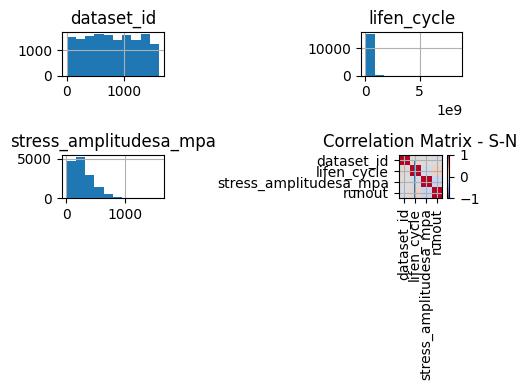

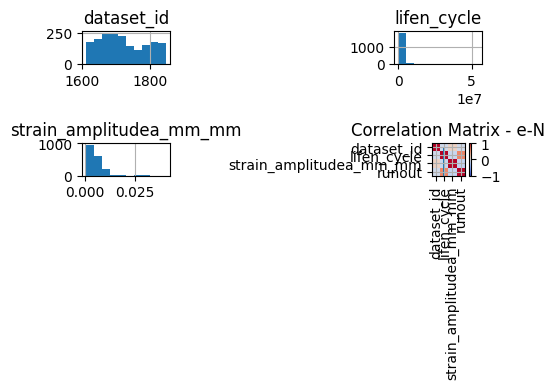

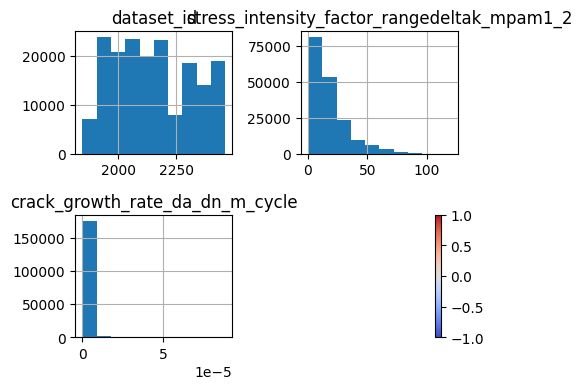

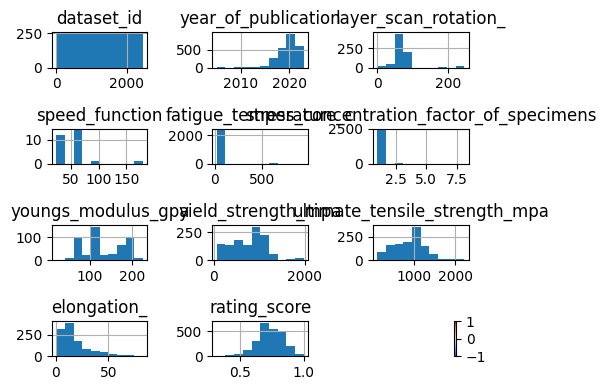

In [38]:
for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    #numerical summary
    df.describe()

    # histograms of numerical columns
    df.hist(figsize=(5,4))

    # correlation matrix
    corr = df.corr(numeric_only=True)

    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(f"Correlation Matrix - {sheet_name}")
    plt.tight_layout()
    plt.show()

# Export Clean Sheet

In [39]:
# export cleaned sheets to one Excel workbook
with pd.ExcelWriter("data_zhou_cleaned.xlsx") as writer:
    for sheet_name, df in cleaned_sheets.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

In [40]:
# metadata only, without the actual dataframe objects
metadata = {}

for sheet_name, info in datasets.items():
    metadata[sheet_name] = {
        key: value
        for key, value in info.items()
        if key != "data"
    }

with open("data_zhou_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)